# Мета

#### У цьому дослідженні я хочу розібратися, як саме війна змінила український футбол. Ми бачимо, що результати наших клубів у Європі погіршилися, і я хочу знайти цьому підтвердження мовою цифр.


#### Моє завдання — перевірити на реальних даних три головні причини цього спаду:
#### Втеча талантів: Наскільки критичним став відтік легіонерів?
#### Досвід: Чи справді наші команди стали занадто молодими для великих перемог?

# Setup

In [1]:
#%pip install seaborn

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib.pyplot import title

### Завантаження даних

In [3]:
apper=pd.read_csv('appearances.csv')

compet=pd.read_csv('competitions.csv')

player_values=pd.read_csv('player_valuations.csv')
players=pd.read_csv('players.csv')


In [4]:
game_links=pd.read_csv('game_lineups.csv')

In [5]:
club_games=pd.read_csv('club_games.csv')

In [6]:
clubs=pd.read_csv('clubs.csv')

### Огляд завантажених даних

In [7]:
apper.head(5)

,appearance_id,game_id,player_id,player_club_id,player_current_club_id,date,player_name,competition_id,yellow_cards,red_cards,goals,assists,minutes_played
0,2231978_38004,2231978,38004,853,235,2012-07-03,Aurélien Joachim,CLQ,0,0,2,0,90
1,2233748_79232,2233748,79232,8841,2698,2012-07-05,Ruslan Abyshov,ELQ,0,0,0,0,90
2,2234413_42792,2234413,42792,6251,465,2012-07-05,Sander Puri,ELQ,0,0,0,0,45
3,2234418_73333,2234418,73333,1274,6646,2012-07-05,Vegar Hedenstad,ELQ,0,0,0,0,90
4,2234421_122011,2234421,122011,195,3008,2012-07-05,Markus Henriksen,ELQ,0,0,0,1,90


In [8]:
clubs.head(5)

,club_id,club_code,name,domestic_competition_id,total_market_value,squad_size,average_age,foreigners_number,foreigners_percentage,national_team_players,stadium_name,stadium_seats,net_transfer_record,coach_name,last_season,filename,url
0,105,sv-darmstadt-98,SV Darmstadt 98,L1,NaN,27,25.6,13,48.1,1,Merck-Stadion am Böllenfalltor,17810,+€3.05m,NaN,2023,../data/raw/transfermarkt-scraper/2023/clubs.j...,https://www.transfermarkt.co.uk/sv-darmstadt-9...
1,11127,ural-ekaterinburg,Ural Yekaterinburg,RU1,NaN,30,26.5,11,36.7,3,Yekaterinburg Arena,23000,+€880k,NaN,2023,../data/raw/transfermarkt-scraper/2023/clubs.j...,https://www.transfermarkt.co.uk/ural-ekaterinb...
2,114,besiktas-istanbul,Beşiktaş Jimnastik Kulübü,TR1,NaN,30,26.6,15,50.0,8,Beşiktaş Park,42445,€-25.26m,NaN,2024,../data/raw/transfermarkt-scraper/2024/clubs.j...,https://www.transfermarkt.co.uk/besiktas-istan...
3,12,as-rom,Associazione Sportiva Roma,IT1,NaN,26,26.3,18,69.2,17,Olimpico di Roma,70634,€-76.90m,NaN,2024,../data/raw/transfermarkt-scraper/2024/clubs.j...,https://www.transfermarkt.co.uk/as-rom/startse...
4,148,tottenham-hotspur,Tottenham Hotspur Football Club,GB1,NaN,30,25.5,21,70.0,18,Tottenham Hotspur Stadium,62850,€-120.05m,NaN,2024,../data/raw/transfermarkt-scraper/2024/clubs.j...,https://www.transfermarkt.co.uk/tottenham-hots...


In [9]:
compet.head(5)

,competition_id,competition_code,name,sub_type,type,country_id,country_name,domestic_league_code,confederation,url,is_major_national_league
0,CIT,italy-cup,italy-cup,domestic_cup,domestic_cup,75,Italy,IT1,europa,https://www.transfermarkt.co.uk/italy-cup/star...,False
1,NLSC,johan-cruijff-schaal,johan-cruijff-schaal,domestic_super_cup,other,122,Netherlands,NL1,europa,https://www.transfermarkt.co.uk/johan-cruijff-...,False
2,GRP,kypello-elladas,kypello-elladas,domestic_cup,domestic_cup,56,Greece,GR1,europa,https://www.transfermarkt.co.uk/kypello-ellada...,False
3,POSU,supertaca-candido-de-oliveira,supertaca-candido-de-oliveira,domestic_super_cup,other,136,Portugal,PO1,europa,https://www.transfermarkt.co.uk/supertaca-cand...,False
4,RUSS,russian-super-cup,russian-super-cup,domestic_super_cup,other,141,Russia,RU1,europa,https://www.transfermarkt.co.uk/russian-super-...,False


In [10]:
game_links.head(5)

,game_lineups_id,date,game_id,player_id,club_id,player_name,type,position,number,team_captain
0,b2dbe01c3656b06c8e23e9de714e26bb,2013-07-27,2317258,1443,610,Christian Poulsen,substitutes,Defensive Midfield,5,0
1,b50a3ec6d52fd1490aab42042ac4f738,2013-07-27,2317258,5017,610,Niklas Moisander,starting_lineup,Centre-Back,4,0
2,7d890e6d0ff8af84b065839966a0ec81,2013-07-27,2317258,9602,1090,Maarten Martens,substitutes,Left Winger,11,0
3,8c355268678b9bbc7084221b1f0fde36,2013-07-27,2317258,12282,610,Daley Blind,starting_lineup,Left-Back,17,0
4,76193074d549e5fdce4cdcbba0d66247,2013-07-27,2317258,25427,1090,Roy Beerens,starting_lineup,Right Winger,23,0


In [11]:
player_values.head(5)

,player_id,date,market_value_in_eur,current_club_id,player_club_domestic_competition_id
0,405973,2000-01-20,150000,3057,BE1
1,342216,2001-07-20,100000,1241,SC1
2,3132,2003-12-09,400000,126,TR1
3,6893,2003-12-15,900000,984,GB1
4,10,2004-10-04,7000000,398,IT1


In [12]:
players.head(5)

,player_id,first_name,last_name,name,last_season,current_club_id,player_code,country_of_birth,city_of_birth,country_of_citizenship,...,foot,height_in_cm,contract_expiration_date,agent_name,image_url,url,current_club_domestic_competition_id,current_club_name,market_value_in_eur,highest_market_value_in_eur
0,10,Miroslav,Klose,Miroslav Klose,2015,398,miroslav-klose,Poland,Opole,Germany,...,right,184.0,NaN,ASBW Sport Marketing,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/miroslav-klose...,IT1,Società Sportiva Lazio S.p.A.,1000000.0,30000000.0
1,26,Roman,Weidenfeller,Roman Weidenfeller,2017,16,roman-weidenfeller,Germany,Diez,Germany,...,left,190.0,NaN,Neubauer 13 GmbH,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/roman-weidenfe...,L1,Borussia Dortmund,750000.0,8000000.0
2,65,Dimitar,Berbatov,Dimitar Berbatov,2015,1091,dimitar-berbatov,Bulgaria,Blagoevgrad,Bulgaria,...,NaN,NaN,NaN,CSKA-AS-23 Ltd.,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/dimitar-berbat...,GR1,Panthessalonikios Athlitikos Omilos Konstantin...,1000000.0,34500000.0
3,77,NaN,Lúcio,Lúcio,2012,506,lucio,Brazil,Brasília,Brazil,...,NaN,NaN,NaN,NaN,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/lucio/profil/s...,IT1,Juventus Football Club,200000.0,24500000.0
4,80,Tom,Starke,Tom Starke,2017,27,tom-starke,East Germany (GDR),Freital,Germany,...,right,194.0,NaN,IFM,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/tom-starke/pro...,L1,FC Bayern München,100000.0,3000000.0


In [13]:
club_games.head(5)

,game_id,club_id,own_goals,own_position,own_manager_name,opponent_id,opponent_goals,opponent_position,opponent_manager_name,hosting,is_win
0,2320450,1468.0,0.0,NaN,Holger Bachthaler,24.0,2.0,NaN,Armin Veh,Home,0
1,2320454,222.0,0.0,NaN,Volkan Uluc,79.0,2.0,NaN,Bruno Labbadia,Home,0
2,2320460,1.0,3.0,NaN,Jürgen Luginger,86.0,1.0,NaN,Robin Dutt,Home,1
3,2320472,2036.0,4.0,NaN,Frank Schmidt,72.0,5.0,NaN,Alexander Schmidt,Home,0
4,2321027,33.0,3.0,8.0,Jens Keller,41.0,3.0,9.0,Thorsten Fink,Home,0


# Очищення даних

#### Перевірка чи є втраченні дані

In [14]:
def missing_data(df):
    for col in df.columns:
        percent_missing=np.mean(df[col].isnull())
        print("{}-{}%".format(col,round(percent_missing *100)))

In [15]:
missing_data(apper)

appearance_id-0%
game_id-0%
player_id-0%
player_club_id-0%
player_current_club_id-0%
date-0%
player_name-0%
competition_id-0%
yellow_cards-0%
red_cards-0%
goals-0%
assists-0%
minutes_played-0%


In [16]:
missing_data(clubs)
"""тут варто зазначити що колонка "total_market_value" на 100% порожня тому її треба буде розрахувати самому
"""

club_id-0%
club_code-0%
name-0%
domestic_competition_id-0%
total_market_value-100%
squad_size-0%
average_age-9%
foreigners_number-0%
foreigners_percentage-11%
national_team_players-0%
stadium_name-0%
stadium_seats-0%
net_transfer_record-0%
coach_name-100%
last_season-0%
filename-0%
url-0%


'тут варто зазначити що колонка "total_market_value" на 100% порожня тому її треба буде розрахувати самому\n'

In [17]:
missing_data(compet)

competition_id-0%
competition_code-0%
name-0%
sub_type-0%
type-0%
country_id-0%
country_name-18%
domestic_league_code-18%
confederation-0%
url-0%
is_major_national_league-0%


In [18]:
missing_data(game_links)

game_lineups_id-0%
date-0%
game_id-0%
player_id-0%
club_id-0%
player_name-0%
type-0%
position-0%
number-0%
team_captain-0%


In [19]:
missing_data(player_values)

player_id-0%
date-0%
market_value_in_eur-0%
current_club_id-0%
player_club_domestic_competition_id-0%


In [20]:
missing_data(players)

player_id-0%
first_name-6%
last_name-0%
name-0%
last_season-0%
current_club_id-0%
player_code-0%
country_of_birth-9%
city_of_birth-8%
country_of_citizenship-1%
date_of_birth-0%
sub_position-1%
position-0%
foot-8%
height_in_cm-7%
contract_expiration_date-37%
agent_name-49%
image_url-0%
url-0%
current_club_domestic_competition_id-0%
current_club_name-0%
market_value_in_eur-5%
highest_market_value_in_eur-5%


In [21]:
missing_data(club_games)

game_id-0%
club_id-0%
own_goals-0%
own_position-30%
own_manager_name-1%
opponent_id-0%
opponent_goals-0%
opponent_position-30%
opponent_manager_name-1%
hosting-0%
is_win-0%


#### Bидалення колонок у яких більше 50% нульові

In [22]:
clubs=clubs.drop(columns=["total_market_value","coach_name"])

#### Редагування колонок де відсоток замалий для того щоб видаляти і завеликий аби просто лишити

In [23]:
players["agent_name"]=players["agent_name"].fillna("Unknown")
players["contract_expiration_date"]=players["contract_expiration_date"].fillna("Unknown")
missing_data(players)
""" переконався, що все спрацювало """


player_id-0%
first_name-6%
last_name-0%
name-0%
last_season-0%
current_club_id-0%
player_code-0%
country_of_birth-9%
city_of_birth-8%
country_of_citizenship-1%
date_of_birth-0%
sub_position-1%
position-0%
foot-8%
height_in_cm-7%
contract_expiration_date-0%
agent_name-0%
image_url-0%
url-0%
current_club_domestic_competition_id-0%
current_club_name-0%
market_value_in_eur-5%
highest_market_value_in_eur-5%


' переконався, що все спрацювало '

#### Видалання порожніх значень

In [24]:
apper=apper.dropna()

In [25]:
clubs=clubs.dropna()

In [26]:
compet=compet.dropna()

In [27]:
game_links=game_links.dropna()

In [28]:
players=players.dropna()

In [29]:
player_values=player_values.dropna()

In [30]:
club_games=club_games.dropna()

#### Перевірка типів даних в колонках

In [31]:
dict_of_tables = {
    "Appearances": apper,
    "Clubs": clubs,
    "Competitions": compet,
    "Game Lineups": game_links,
    "Player Valuations": player_values,
    "Players": players
}

In [32]:
for name, df in dict_of_tables.items():
    print("-" * 50)
    print(f"Таблиця: {name}")
    print("-" * 50)
    print(df.dtypes) # Виводимо типи даних
    print("\n")


--------------------------------------------------
Таблиця: Appearances
--------------------------------------------------
appearance_id               str
game_id                   int64
player_id                 int64
player_club_id            int64
player_current_club_id    int64
date                        str
player_name                 str
competition_id              str
yellow_cards              int64
red_cards                 int64
goals                     int64
assists                   int64
minutes_played            int64
dtype: object


--------------------------------------------------
Таблиця: Clubs
--------------------------------------------------
club_id                      int64
club_code                      str
name                           str
domestic_competition_id        str
squad_size                   int64
average_age                float64
foreigners_number            int64
foreigners_percentage      float64
national_team_players        int64
stadium_name 

### Перейдемо до первріки гіпотез

#### первірка першої гіпотези

In [33]:
ukt_comp=compet[compet["country_name"]=="Ukraine"]

In [34]:
ukt_comp

,competition_id,competition_code,name,sub_type,type,country_id,country_name,domestic_league_code,confederation,url,is_major_national_league
24,UKRS,ukrainian-super-cup,ukrainian-super-cup,domestic_super_cup,other,177,Ukraine,UKR1,europa,https://www.transfermarkt.co.uk/ukrainian-supe...,False
25,UKR1,premier-liga,premier-liga,first_tier,domestic_league,177,Ukraine,UKR1,europa,https://www.transfermarkt.co.uk/premier-liga/s...,False
41,UKRP,ukrainian-cup,ukrainian-cup,domestic_cup,domestic_cup,177,Ukraine,UKR1,europa,https://www.transfermarkt.co.uk/ukrainian-cup/...,False


In [35]:
target_competitions = ["UKR1", "UKRS", "UKRP"]
ukr_clubs = clubs[clubs["domestic_competition_id"].isin(target_competitions)].drop_duplicates()

In [36]:
ukr_clubs.head(100)

,club_id,club_code,name,domestic_competition_id,squad_size,average_age,foreigners_number,foreigners_percentage,national_team_players,stadium_name,stadium_seats,net_transfer_record,last_season,filename,url
42,2740,vorskla-poltava,Vorskla Poltava,UKR1,26,25.5,5,19.2,1,Vorskla im. Oleksiy Butovskyi,23842,+€2.60m,2024,../data/raw/transfermarkt-scraper/2024/clubs.j...,https://www.transfermarkt.co.uk/vorskla-poltav...
53,55686,metalist-1925-kharkiv,Metalist 1925 Kharkiv,UKR1,32,25.7,2,6.3,0,Stadion Kolos,0,€-620k,2023,../data/raw/transfermarkt-scraper/2023/clubs.j...,https://www.transfermarkt.co.uk/metalist-1925-...
58,83678,metal-kharkiv,Metalist Kharkiv,UKR1,25,26.1,7,28.0,0,Avangard,10640,+€300k,2022,../data/raw/transfermarkt-scraper/2022/clubs.j...,https://www.transfermarkt.co.uk/metal-kharkiv/...
172,86209,fk-livyi-bereg,FK Livyi Bereh,UKR1,24,26.3,2,8.3,0,Arena Livyi Bereg,4700,+-0,2024,../data/raw/transfermarkt-scraper/2024/clubs.j...,https://www.transfermarkt.co.uk/fk-livyi-bereg...
174,10690,zorya-lugansk,FC Zorya Lugansk,UKR1,26,24.7,7,26.9,0,Valeriy Lobanovsky Stadion,16873,+€3.90m,2024,../data/raw/transfermarkt-scraper/2024/clubs.j...,https://www.transfermarkt.co.uk/zorya-lugansk/...
256,18303,fk-oleksandriya,FC Oleksandriya,UKR1,29,26.3,5,17.2,1,KSK Nika,7000,€-480k,2024,../data/raw/transfermarkt-scraper/2024/clubs.j...,https://www.transfermarkt.co.uk/fk-oleksandriy...
259,26459,nk-veres-rivne,NK Veres Rivne,UKR1,23,25.8,5,21.7,1,Stadion Avangard (2022),7122,+€230k,2024,../data/raw/transfermarkt-scraper/2024/clubs.j...,https://www.transfermarkt.co.uk/nk-veres-rivne...
265,338,dynamo-kiew,Futbolniy Klub Dynamo Kyiv,UKR1,28,25.2,2,7.1,9,Valeriy Lobanovsky Stadion,16873,€-1.30m,2024,../data/raw/transfermarkt-scraper/2024/clubs.j...,https://www.transfermarkt.co.uk/dynamo-kiew/st...
269,6992,chornomorets-odessa,ZAO FK Chornomorets Odessa,UKR1,36,24.4,12,33.3,3,Stadion Chornomorets (2011),34164,+€1.03m,2024,../data/raw/transfermarkt-scraper/2024/clubs.j...,https://www.transfermarkt.co.uk/chornomorets-o...
316,48726,rukh-lviv,FC Rukh Lviv,UKR1,26,22.8,4,15.4,1,Arena Lviv,34725,+€2.00m,2024,../data/raw/transfermarkt-scraper/2024/clubs.j...,https://www.transfermarkt.co.uk/rukh-lviv/star...


In [37]:
club_subset = ukr_clubs[['club_id', 'name']]
game_line_subset=game_links[['club_id', 'date',"player_id"]]
players_subset=players[["name", 'player_id',"country_of_citizenship"]]

In [38]:
players_games=pd.merge(players_subset,game_line_subset,on='player_id',how="outer")

In [39]:
target_id=ukr_clubs["club_id"].tolist()
players_for_ukr_clubs=players_games[ (players_games["club_id"].isin(target_id))]



In [40]:
players_for_ukr_clubs

,name,player_id,country_of_citizenship,club_id,date
22225,Markus Berger,4678,Austria,6992.0,2013-07-10
22226,Markus Berger,4678,Austria,6992.0,2013-07-14
22227,Markus Berger,4678,Austria,6992.0,2013-07-21
22228,Markus Berger,4678,Austria,6992.0,2013-07-28
22229,Markus Berger,4678,Austria,6992.0,2013-08-11
...,...,...,...,...,...
2193678,NaN,1240468,NaN,26459.0,2024-03-17
2193701,NaN,1244432,NaN,10690.0,2024-03-12
2193702,NaN,1244433,NaN,10690.0,2024-03-12
2193703,NaN,1244434,NaN,10690.0,2024-03-12


In [41]:

players_for_ukr_clubs['date'] = pd.to_datetime(players_for_ukr_clubs['date'])
players_for_ukr_clubs['year'] = players_for_ukr_clubs['date'].dt.year



In [42]:
players_for_ukr_clubs.info()

<class 'pandas.DataFrame'>
Index: 46610 entries, 22225 to 2193704
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   name                    40205 non-null  str           
 1   player_id               46610 non-null  int64         
 2   country_of_citizenship  40205 non-null  str           
 3   club_id                 46610 non-null  float64       
 4   date                    46610 non-null  datetime64[us]
 5   year                    46610 non-null  int32         
dtypes: datetime64[us](1), float64(1), int32(1), int64(1), str(2)
memory usage: 2.3 MB


In [43]:
players_for_ukr_clubs["year"]=players_for_ukr_clubs["date"].dt.year

In [44]:
players_for_ukr_clubs.drop(columns=["date"])

,name,player_id,country_of_citizenship,club_id,year
22225,Markus Berger,4678,Austria,6992.0,2013
22226,Markus Berger,4678,Austria,6992.0,2013
22227,Markus Berger,4678,Austria,6992.0,2013
22228,Markus Berger,4678,Austria,6992.0,2013
22229,Markus Berger,4678,Austria,6992.0,2013
...,...,...,...,...,...
2193678,NaN,1240468,NaN,26459.0,2024
2193701,NaN,1244432,NaN,10690.0,2024
2193702,NaN,1244433,NaN,10690.0,2024
2193703,NaN,1244434,NaN,10690.0,2024


In [45]:
players_for_ukr_clubs=players_for_ukr_clubs.drop_duplicates(subset=["year", "player_id"])

In [46]:
payers_country = players_for_ukr_clubs.groupby(["year","country_of_citizenship"])["player_id"].count().reset_index(name="player_count")

In [47]:
payers_country


,year,country_of_citizenship,player_count
0,2013,Albania,3
1,2013,Argentina,2
2,2013,Austria,2
3,2013,Bosnia-Herzegovina,1
4,2013,Brazil,3
...,...,...,...
292,2024,Serbia,1
293,2024,Slovenia,2
294,2024,Tanzania,1
295,2024,Ukraine,274


In [48]:
payers_country_ukr = payers_country[payers_country["country_of_citizenship"] == "Ukraine"]

In [49]:
payers_country_ukr

,year,country_of_citizenship,player_count
21,2013,Ukraine,93
45,2014,Ukraine,128
63,2015,Ukraine,147
80,2016,Ukraine,172
99,2017,Ukraine,209
120,2018,Ukraine,220
146,2019,Ukraine,223
173,2020,Ukraine,285
209,2021,Ukraine,361
238,2022,Ukraine,303


In [50]:
payers_country_notukr = payers_country[payers_country["country_of_citizenship"] != "Ukraine"]

In [51]:
payers_country_notukr

,year,country_of_citizenship,player_count
0,2013,Albania,3
1,2013,Argentina,2
2,2013,Austria,2
3,2013,Bosnia-Herzegovina,1
4,2013,Brazil,3
...,...,...,...
291,2024,Senegal,2
292,2024,Serbia,1
293,2024,Slovenia,2
294,2024,Tanzania,1


In [52]:
total_not_ukr_pl=payers_country_notukr.groupby("year")["player_count"].sum().reset_index()

In [53]:
total_not_ukr_pl

,year,player_count
0,2013,36
1,2014,36
2,2015,30
3,2016,25
4,2017,28
5,2018,28
6,2019,33
7,2020,42
8,2021,61
9,2022,30


### Графік який показує як змінювалась кількість легіонерів тобто гравців з інших країн грали кожного року в укр. чемпіонаті

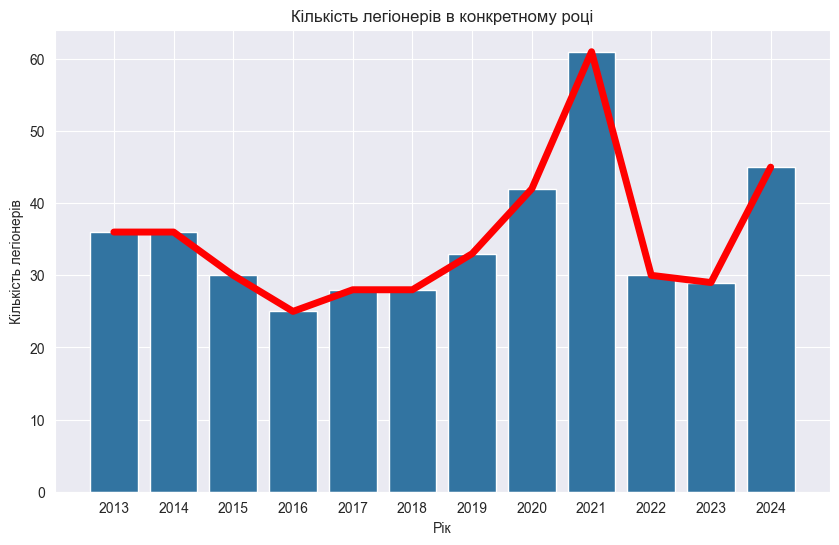

In [54]:
total_not_ukr_pl["year"]=total_not_ukr_pl["year"].astype(str)#щоб графіки нормально співпрацювали
plt.figure(figsize = (10,6),)
sns.barplot(data=total_not_ukr_pl,x="year",y="player_count")
sns.lineplot(data=total_not_ukr_pl, x="year", y="player_count", color="red", linewidth=5)
sns.set_color_codes("bright")
plt.xlabel("Рік")
plt.ylabel("Кількість легіонерів")
plt.title("Кількість легіонерів в конкретному році")
plt.grid(True)
plt.show()


##### Очевидно, що кількість легіонерів в 2022 році різко знизилась і продовжувала знижуватись протягом 2023. Також варто зазначити, загалом кількість легіонерів приблизно ж така як і в 2015,2016, 2017 та 2018. Це повністю спростовую гіпотезу,що результати напряму залежать від кількості легіонерів, бо якщо згадати 2015,2016, 2017 та 2018 роки то можна зауважити, що результати українських команд були сильно кращими ніж у 2022-2024 роках

### Перевірка гіпотези "Чи справді наші команди стали занадто молодими для великих перемог?"

#### Підготовка даних

In [55]:
players_age=players[["player_id","date_of_birth"]]

In [56]:
players_age

,player_id,date_of_birth
0,10,1978-06-09 00:00:00
1,26,1980-08-06 00:00:00
4,80,1981-03-18 00:00:00
7,132,1980-10-04 00:00:00
8,162,1976-06-13 00:00:00
...,...,...
32580,1294049,2006-05-25 00:00:00
32581,1294052,2006-01-10 00:00:00
32584,1306131,2007-09-06 00:00:00
32585,1306851,2005-02-19 00:00:00


In [57]:
players_for_ukr_clubs=pd.merge(players_for_ukr_clubs,players_age,on="player_id",how="left")
players_for_ukr_clubs

,name,player_id,country_of_citizenship,club_id,date,year,date_of_birth
0,Markus Berger,4678,Austria,6992.0,2013-07-10,2013,1985-01-21 00:00:00
1,Markus Berger,4678,Austria,6992.0,2014-02-20,2014,1985-01-21 00:00:00
2,NaN,8480,NaN,6992.0,2013-07-10,2013,NaN
3,Tomas Hübschman,9688,Czech Republic,660.0,2013-07-10,2013,1981-09-04 00:00:00
4,Tomas Hübschman,9688,Czech Republic,660.0,2014-04-19,2014,1981-09-04 00:00:00
...,...,...,...,...,...,...,...
3913,NaN,1240468,NaN,26459.0,2024-03-02,2024,NaN
3914,NaN,1244432,NaN,10690.0,2024-03-12,2024,NaN
3915,NaN,1244433,NaN,10690.0,2024-03-12,2024,NaN
3916,NaN,1244434,NaN,10690.0,2024-03-12,2024,NaN


In [58]:
players_for_ukr_clubs=players_for_ukr_clubs.dropna()

In [59]:
players_for_ukr_clubs

,name,player_id,country_of_citizenship,club_id,date,year,date_of_birth
0,Markus Berger,4678,Austria,6992.0,2013-07-10,2013,1985-01-21 00:00:00
1,Markus Berger,4678,Austria,6992.0,2014-02-20,2014,1985-01-21 00:00:00
3,Tomas Hübschman,9688,Czech Republic,660.0,2013-07-10,2013,1981-09-04 00:00:00
4,Tomas Hübschman,9688,Czech Republic,660.0,2014-04-19,2014,1981-09-04 00:00:00
5,Oleksandr Shovkovskyi,9775,Ukraine,338.0,2013-07-14,2013,1975-01-02 00:00:00
...,...,...,...,...,...,...,...
3905,Sergiy Korniychuk,1159925,Ukraine,61825.0,2024-02-25,2024,2004-06-25 00:00:00
3906,Viktor Dolgyi,1160405,Ukraine,18303.0,2024-02-26,2024,2004-01-02 00:00:00
3908,Danyil Checher,1173335,Ukraine,53646.0,2024-02-25,2024,2004-11-17 00:00:00
3910,Samuel Obinaya,1237999,Ukraine,55686.0,2024-02-25,2024,2005-08-28 00:00:00


In [60]:
players_for_ukr_clubs["date_of_birth"]=pd.to_datetime(players_for_ukr_clubs["date_of_birth"])

In [61]:
players_for_ukr_clubs["year_of_birth"] = players_for_ukr_clubs["date_of_birth"].dt.year

In [62]:
players_for_ukr_clubs["current_age"]=players_for_ukr_clubs["year"]-players_for_ukr_clubs["year_of_birth"]

In [63]:
list_of_ukr_best_clubs_id=[660,338,83678,10690]
""" це список id тих клубів які найчастіше брали участь в єврокубках за історію урк чемпіонату"""

' це список id тих клубів які найчастіше брали участь в єврокубках за історію урк чемпіонату'

In [64]:
players_for_best_ukr_clubs=players_for_ukr_clubs[players_for_ukr_clubs["club_id"].isin(list_of_ukr_best_clubs_id)]
players_for_best_ukr_clubs

,name,player_id,country_of_citizenship,club_id,date,year,date_of_birth,year_of_birth,current_age
3,Tomas Hübschman,9688,Czech Republic,660.0,2013-07-10,2013,1981-09-04,1981,32
4,Tomas Hübschman,9688,Czech Republic,660.0,2014-04-19,2014,1981-09-04,1981,33
5,Oleksandr Shovkovskyi,9775,Ukraine,338.0,2013-07-14,2013,1975-01-02,1975,38
6,Oleksandr Shovkovskyi,9775,Ukraine,338.0,2014-02-20,2014,1975-01-02,1975,39
7,Oleksandr Shovkovskyi,9775,Ukraine,338.0,2015-04-08,2015,1975-01-02,1975,40
...,...,...,...,...,...,...,...,...,...
3793,Andriy Matkevych,955213,Ukraine,338.0,2024-03-12,2024,2005-01-11,2005,19
3843,Viktor Tsukanov,1057222,Ukraine,660.0,2024-02-26,2024,2006-02-04,2006,18
3844,Oleksandr Nikolyshyn,1059104,Ukraine,83678.0,2023-03-11,2023,2004-07-20,2004,19
3850,Taras Mykhavko,1067225,Ukraine,338.0,2024-02-25,2024,2005-05-30,2005,19


In [65]:
players_for_top_ukr_clubs_by_year=players_for_best_ukr_clubs.groupby(["year","club_id"])["current_age"].mean().reset_index().round(2)


In [66]:
players_for_top_ukr_clubs_by_year

,year,club_id,current_age
0,2013,338.0,25.17
1,2013,660.0,24.95
2,2013,10690.0,25.46
3,2014,338.0,24.73
4,2014,660.0,25.65
5,2014,10690.0,24.45
6,2015,338.0,25.15
7,2015,660.0,24.45
8,2015,10690.0,25.52
9,2016,338.0,25.21


### Графік який показує як змінювався середній вік 4 найкращих укр команд

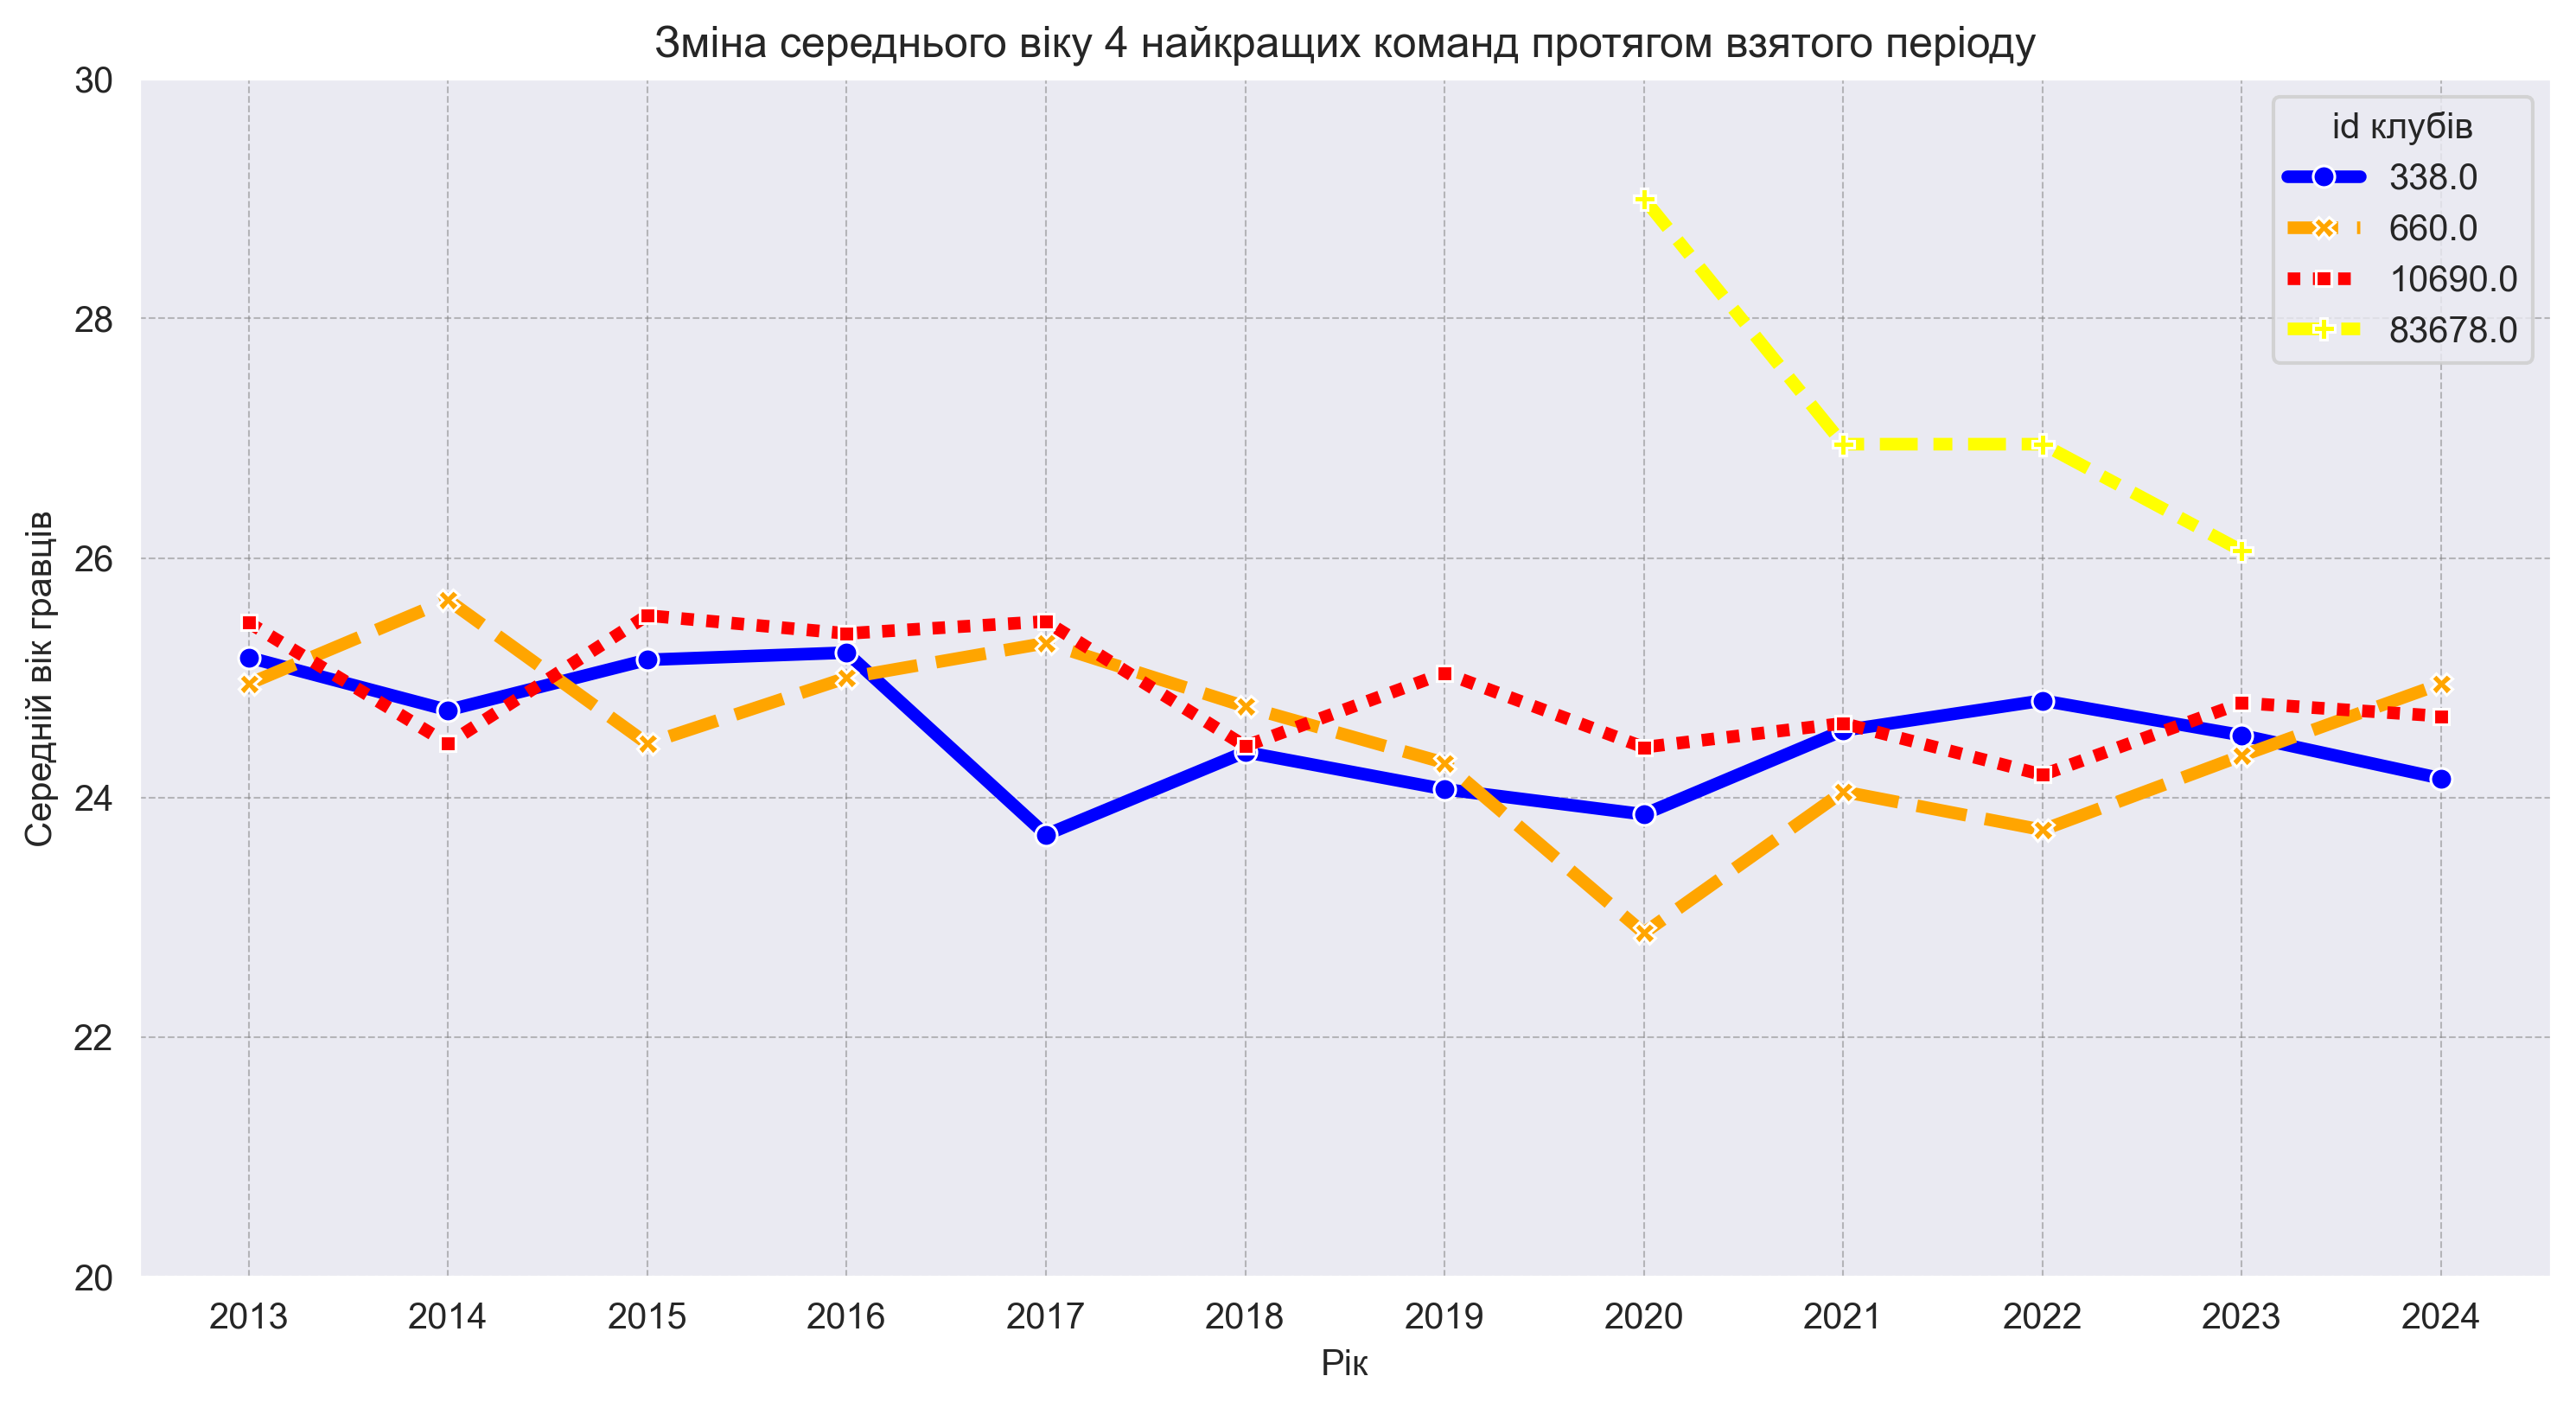

In [67]:
unique_years = players_for_top_ukr_clubs_by_year["year"].unique()
colors={338.0:"blue",
       660.0:"orange",
    83678.0: "yellow",
    10690.0:"red"}
plt.figure(figsize = (12,6),dpi=300)
sns.lineplot(data=players_for_top_ukr_clubs_by_year,x="year",y="current_age",hue="club_id",marker="o",style="club_id",dashes=True,markers=True,linewidth=3.5,palette=colors)
plt.grid(True)
plt.xticks(sorted(unique_years))

plt.grid(
    visible=True,
    color="grey",
    linestyle="--",
    linewidth=0.5,
    alpha=0.5
)
plt.ylim(20,30)
plt.xlabel("Рік")
plt.ylabel("Середній вік гравців")
plt.title("Зміна середнього віку 4 найкращих команд протягом взятого періоду")
plt.xticks(sorted(unique_years))
plt.legend(title="id клубів")

#### Загалом цей графік був побудований з метою побачити, як змінювався середній вік наших команд. Тут видно, що 3 з 4 команд мають середній вік складу від 23 до 25 років. Лише дуже помітно, як команда з індексом 83678.0 різко почала омолоджувати склад. Це сталося через початок відродження цієї команди та вихід її до Першої ліги, тому команда була змушена омолоджувати склад, аби складати конкуренцію більш іменитим суперникам



### Аби точно перевіреконатися, що вік не є причиною поганих результатів,візьмемо команду яка мала погані результати і наші топ 3 команди та порівняємо середній вік їхнух складів


##### id команди з поганими резульатами  2740

In [68]:
list_of_ukr_clubs_id=[660,338,2740,10690]#

In [69]:
players_for_ukr_clubs3=players_for_ukr_clubs[players_for_ukr_clubs["club_id"].isin(list_of_ukr_clubs_id)]
players_for_ukr_clubs

,name,player_id,country_of_citizenship,club_id,date,year,date_of_birth,year_of_birth,current_age
0,Markus Berger,4678,Austria,6992.0,2013-07-10,2013,1985-01-21,1985,28
1,Markus Berger,4678,Austria,6992.0,2014-02-20,2014,1985-01-21,1985,29
3,Tomas Hübschman,9688,Czech Republic,660.0,2013-07-10,2013,1981-09-04,1981,32
4,Tomas Hübschman,9688,Czech Republic,660.0,2014-04-19,2014,1981-09-04,1981,33
5,Oleksandr Shovkovskyi,9775,Ukraine,338.0,2013-07-14,2013,1975-01-02,1975,38
...,...,...,...,...,...,...,...,...,...
3905,Sergiy Korniychuk,1159925,Ukraine,61825.0,2024-02-25,2024,2004-06-25,2004,20
3906,Viktor Dolgyi,1160405,Ukraine,18303.0,2024-02-26,2024,2004-01-02,2004,20
3908,Danyil Checher,1173335,Ukraine,53646.0,2024-02-25,2024,2004-11-17,2004,20
3910,Samuel Obinaya,1237999,Ukraine,55686.0,2024-02-25,2024,2005-08-28,2005,19


In [70]:
players_for_ukr_clubs3=players_for_ukr_clubs3.groupby(["year","club_id"])["current_age"].mean().reset_index().round(2)

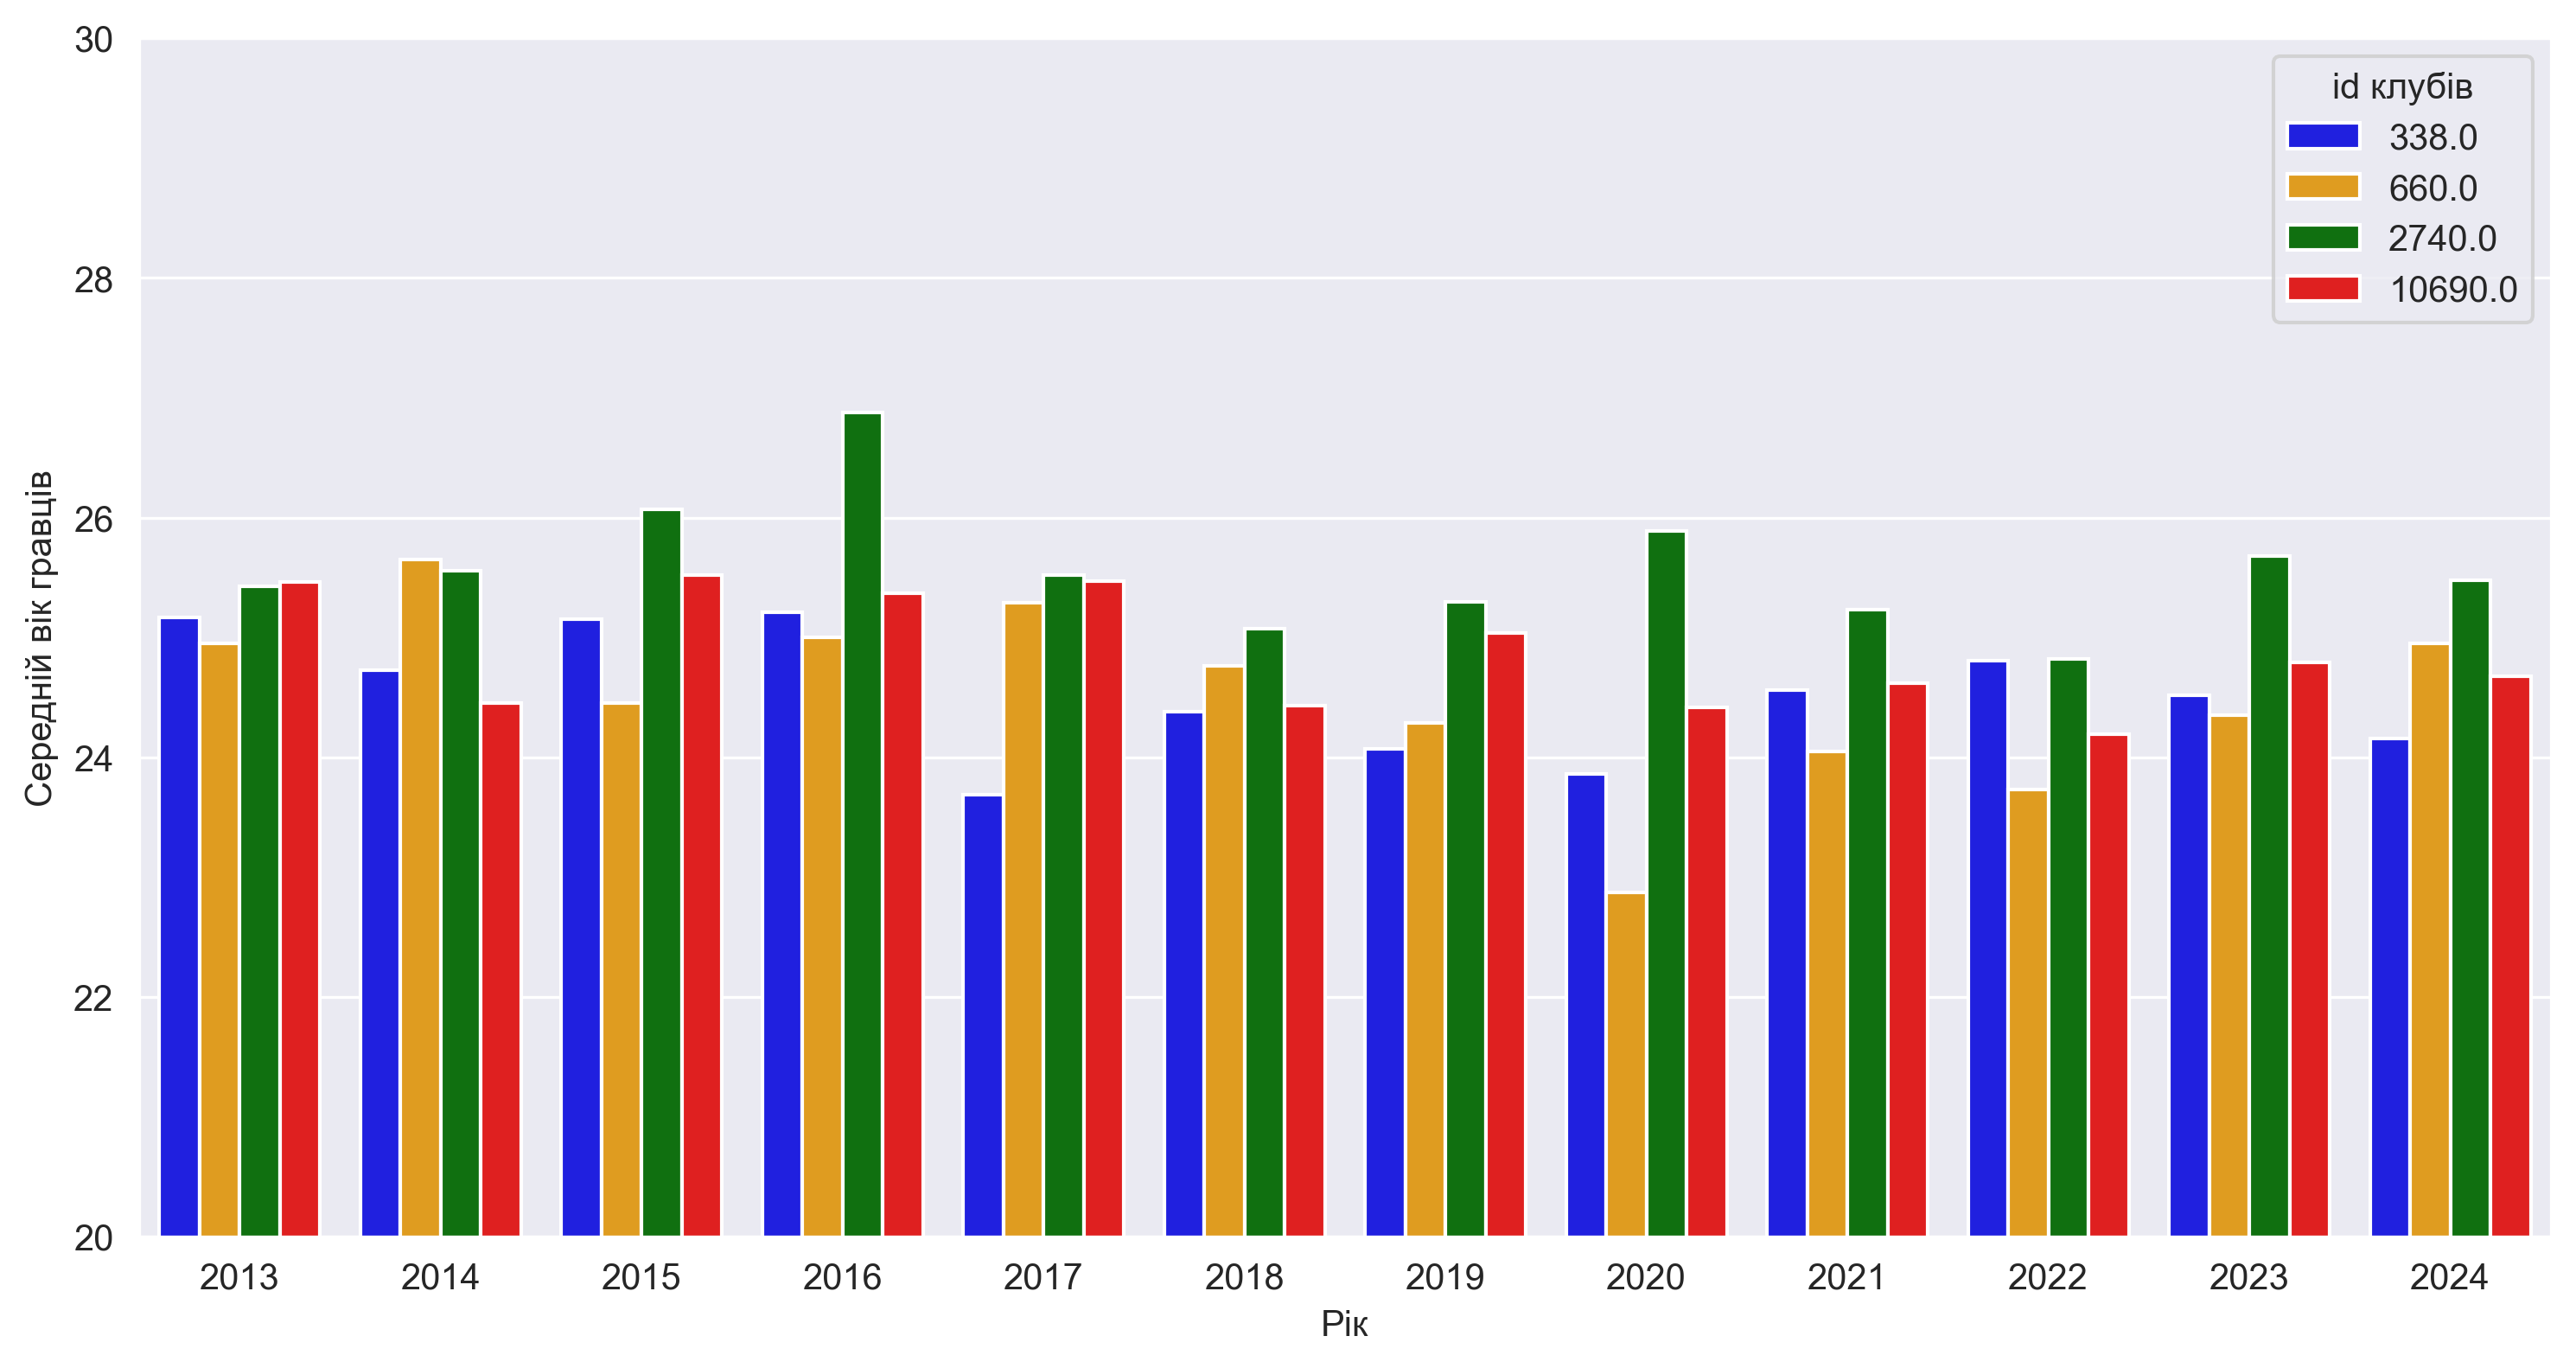

In [71]:
plt.figure(figsize = (12,6),dpi=300)
colors={338.0:"blue",
       660.0:"orange",
    2740: "green",
    10690.0:"red"}
sns.barplot(data=players_for_ukr_clubs3,x="year",y="current_age",hue="club_id",palette=colors)
plt.ylim(20,30)
plt.xlabel("Рік")
plt.ylabel("Cередній вік гравців")
plt.legend(title="id клубів")
plt.show()

#### Аналіз графіка демонструє, що середній вік команди 2740 зазвичай перевищував показники інших клубів. Варто зазначити, що у 2016 році склад команди був значно старшим за конкурентів, проте спортивні результати залишалися на середньому рівні, тоді як 2024 рік став провальним. Це дозволяє припустити, що віковий фактор негативно впливає на результативність лише в тому випадку, коли середній вік команди значно перевищує 28 років.